Looking at each pixel along the center row

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


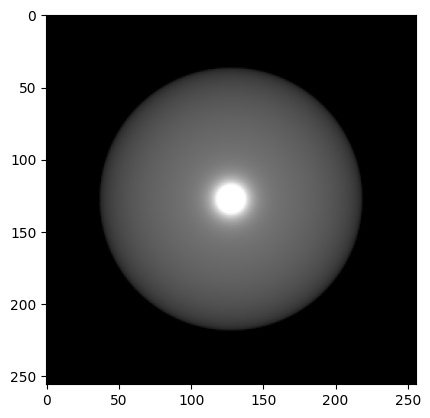

In [1]:
# SYNTHETIC SCENE SETUP
import ivt
from ivt.scene import Scene, DiffuseBRDF, MicrofacetBRDF, Mesh, \
    PerspectiveCamera, HDRFilm, Integrator, EnvironmentLight
from ivt.io import read_image, read_mesh, write_image
from ivt.sampling import sample_sphere

from matplotlib import pyplot as plt
import torch
import numpy as np

scene = Scene()

# material
scene.set('mat', MicrofacetBRDF(0.3, 0.3, 0.3))
scene.set('mesh1', Mesh.from_file("assets/meshes/sphere.obj", 'mat')) # surface to reconstruct
scene.set('film', HDRFilm(256, 256))
scene.set('integrator', Integrator('collocated', {'intensity':1}))
# scene.set('cam1', PerspectiveCamera.from_lookat(fov=40, origin=(1,0.5,0), target=(0,0,0), up=(0,1,0))) # camera

# randomly generate cameras
num_sensors = 1
fov = 40
radius = 1
target = (0,0,0)
up = (0,1,0)
for i, origin in enumerate(sample_sphere(num_sensors, radius, 'fibonacci')):
    scene.set(f'sensor {i}', PerspectiveCamera.from_lookat(fov, origin, target, up))

# render target images
renderer = ivt.renderer.Renderer(connector_name='psdr_jit', render_options = {
    "spp": 16,
    "sppe": 0,
    "sppse": 0,
    "npass": 1,
    "log_level": 0
})
# because ivt has a glitch that doesn't update changes in spp, workaround here to render a higher spp target image
I_t = torch.stack([renderer(scene, sensor_ids=range(num_sensors)) for _ in range(16)]).mean(axis=0)

# Visualize a target Image
def showimg(I):
    plt.imshow((I**0.454).detach().cpu().numpy().squeeze(), vmax=1)
showimg(I_t)

In [45]:
# measure the variance of the render on each pixel
from tqdm.notebook import tqdm
sigma = torch.std(torch.stack([renderer(scene, sensor_ids=range(num_sensors)) for _ in tqdm(range(400))]), dim=0)

  0%|          | 0/400 [00:00<?, ?it/s]

In [16]:
sigma.shape

torch.Size([1, 256, 256, 3])

In [26]:
sigma.detach().cpu().numpy().squeeze().max()

0.064100966

In [35]:
sigma.mean()

tensor(0.0003, device='cuda:0')

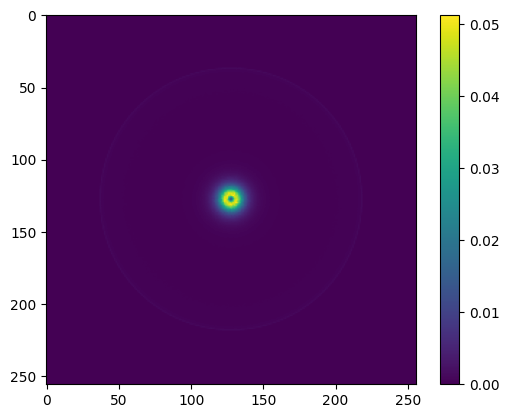

In [49]:
plt.imshow(sigma[...,1].cpu()[0])
plt.colorbar()

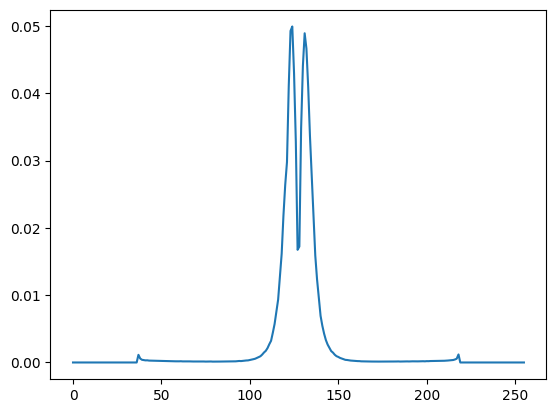

In [51]:
plt.plot(sigma[0,128,...,1].cpu().numpy())